# M5A4 - Sistema de Vigilância

Na prática de hoje vamos refinar um modelo para a tarefa de sistema de vigilância.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Validar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Também será necessária a instalação do `ffmpeg` mais detalhes nesse [link](https://www.ffmpeg.org/download.html).

Para usuários linux e possivelmente em ambientes wsl.

```console
sudo apt update; sudo apt install ffmpeg -y
```


Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision datasets tqdm ipywidgets torchcodec torchvideo ffmpeg-python av

Importar as bibliotecas

In [2]:
import datasets
import torch
import torchvision
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torchcodec

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://huggingface.co/datasets/ertiaM/Anomaly_Detection_in_Surveillance_Videos

In [3]:
# Baixando dataset.
# Esse dataset possui apenas split de treino.
dataset = datasets.load_dataset("ertiaM/Anomaly_Detection_in_Surveillance_Videos", split="train")

# Split dataset.
split_ds = dataset.train_test_split(test_size=0.1, seed=42)

# Pegar splits de dados.
train_dataset = split_ds["train"]
test_dataset = split_ds["test"]


# Transformações dos dados para treino.
def transforms(examples):
    # Pré processamento do modelo.
    preprocess = torchvision.models.video.Swin3D_T_Weights.KINETICS400_V1.transforms()
    #Transformações das imagens.
    transforms = torchvision.transforms.Compose([
        preprocess, # Pré processamento do modelo
    ])

    videos = []
    targets = []
    for video, label in zip(examples["video"], examples["label"]):
        # Cria os clips.
        num_clips = 5
        clips =  torchcodec.samplers.clips_at_random_indices(video,
                                                             num_clips=num_clips,
                                                             num_frames_per_clip=4,
                                                             num_indices_between_frames=3)

        # Processando os clips e organizando os labels.
        clips = [transforms(clip.data) for clip in clips]
        labels = torch.tensor(label).repeat(num_clips)
        
        videos.append(torch.stack(clips))
        targets.append(labels)
    videos = [clip for video in videos for clip in video]
    targets = [label for target in targets for label in target]
    return {"video": videos, "target": targets}

train_dataset =  train_dataset.with_transform(transforms)
# test_dataset = test_dataset.with_transform(test_transforms)

def collate_fn(batch):
    # Organiza o retorno do dataloader.
    videos = torch.stack([item["video"] for item in batch])
    targets = torch.stack([item["target"] for item in batch])
    return videos, targets

# Criando dataloaders.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/950 [00:00<?, ?it/s]

## Refinar Modelo

Na prática de hoje iremos refinar o modelo **Swin Transformer 3D** disponível no torchvision.

In [4]:
# Definindo dispositivo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carregando modelo.
model = torchvision.models.video.swin3d_t(weights=torchvision.models.video.Swin3D_T_Weights.KINETICS400_V1)

num_classes = 13 # número de classes no nosso dataset.
in_features = model.head.in_features # número de features da última camada.
model.head = torch.nn.Linear(in_features, num_classes) # substitui a última camada do modelo.

model.to(device) # Colocando modelo no dispositivo.

# Definindo o otimizador.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

# Define a função de perda.
loss = torch.nn.CrossEntropyLoss()

# Treinamento do modelo
model.train()
epochs = 10 # Alterar para treinar mais epocas.
for epoch in range(epochs):
    iteration = 0
    for videos, labels in tqdm(train_loader):
        # Muda o dispostivo de processamento dos dados.
        videos = videos.to(device)
        labels = labels.to(device)

        # Processa os dados.
        output = model(videos)

        # Computa loss.
        loss_value = loss(output, labels)

        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        
        if iteration % 100 == 0:
            print(f"Total loss: {loss_value.item()}")
        iteration += 1

  0%|          | 0/214 [00:00<?, ?it/s]

Total loss: 2.5477938652038574
Total loss: 1.996769905090332
Total loss: 1.9984588623046875


  0%|          | 0/214 [00:00<?, ?it/s]

Total loss: 2.0746264457702637
Total loss: 2.3489043712615967
Total loss: 2.305896043777466


  0%|          | 0/214 [00:00<?, ?it/s]

...

Total loss: 0.3236747980117798
Total loss: 0.31239503622055054
Total loss: 0.3449060916900635


  0%|          | 0/214 [00:00<?, ?it/s]

Total loss: 0.6045922040939331
Total loss: 0.6938988566398621
Total loss: 0.49753695726394653


  0%|          | 0/214 [00:00<?, ?it/s]

Total loss: 0.3854292035102844
Total loss: 0.24144676327705383
Total loss: 0.03681947663426399


## Validar Modelo

Agora vamos testar o nosso modelo.

Predição: Stealing


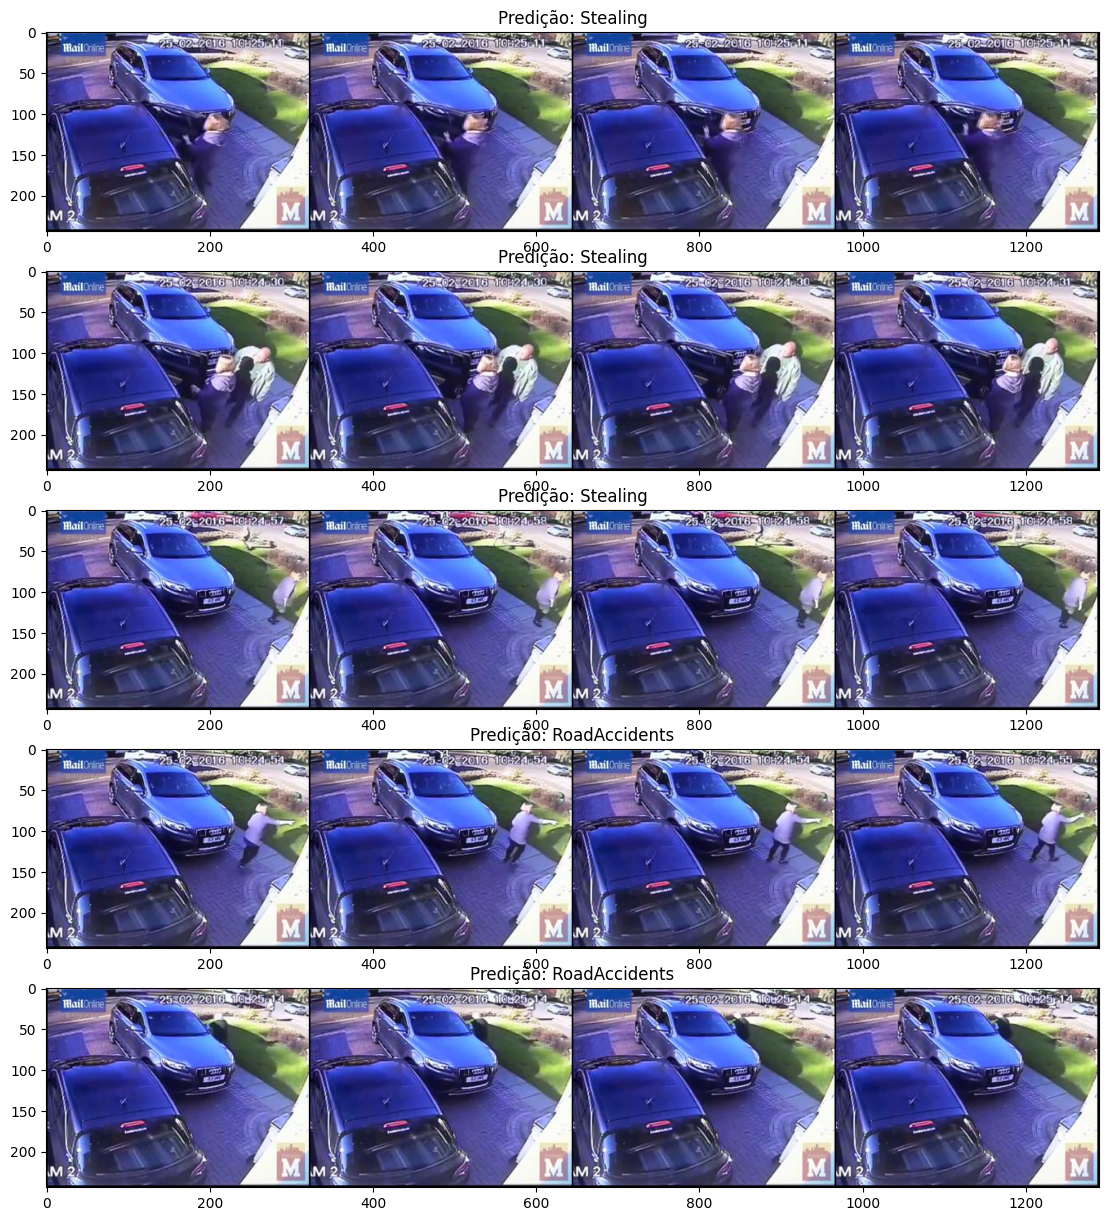

In [ ]:
# Tamanho do dataset de treino.
len_test_data = len(test_dataset)

# Sortear amostra do dataset de teste.
idx = torch.randint(len_test_data, (1,))

# Pré processamento para o modelo.
preprocess = torchvision.models.video.Swin3D_T_Weights.KINETICS400_V1.transforms()

# Modelo em modo de avaliação.
model.eval()
with torch.no_grad():
    video = test_dataset[idx]["video"][0]

    clips =  torchcodec.samplers.clips_at_random_indices(video,
                                                        num_clips=5,
                                                        num_frames_per_clip=4,
                                                        num_indices_between_frames=3)
    
    x = [preprocess(clip.data) for clip in clips]
    images = torch.stack([clip.data for clip in clips])
    # Processa os clips e coloca no dispositivo. 
    x = torch.stack(x).to(device)
    predictions = model(x)

probs = torch.argmax(torch.softmax(predictions, dim=1), dim=1)
inverse_label_map = {7: "RoadAccidents",
                     8: "Robbery",
                     4: "Burglary",
                     11: "Stealing",
                     0: "Abuse",
                     1: "Arrest",
                     2: "Arson",
                     3: "Assault",
                     5: "Explosion",
                     6: "Fighting",
                     9: "Shooting",
                     10: "Shoplifting",
                     12: "Vandalism"}

print(f"Predição: {inverse_label_map[int(probs[0].cpu())]}")

fig, ax = plt.subplots(5, 1,  figsize=(20, 15)) # Cria uma figura e um eixo
for i in range(5):
    ax[i].imshow(torchvision.transforms.functional.to_pil_image(torchvision.utils.make_grid(images[i])))
    ax[i].set_title(f"Predição: {inverse_label_map[int(probs[i].cpu())]}") # Coloca título a classe.

plt.show() # Exibe o gráfico final (bloqueia)

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://huggingface.co/datasets/ertiaM/Anomaly_Detection_in_Surveillance_Videos
- https://huggingface.co/datasets
- https://docs.pytorch.org/vision/main/models/generated/torchvision.models.video.swin3d_t.html#torchvision.models.video.swin3d_t
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente por mais tempo melhora os resultados?
- [ ] Tente alterar alguns hiperparâmetros de treinamento, batch, quantidade de frames por clip, learning rate e veja como isso altera os resultados.